## 0. Download dataset
**Note:** If you can't download using gdown due to limited number of downloads, please download it manually and upload it to your drive, then copy it from the drive to colab.
```python
from google.colab import drive

drive.mount('/content/drive')
!cp /path/to/dataset/on/your/drive .
```

In [24]:
!gdown --id 1uYXI4O3oWBA6QC8ZJ-r6yaTTfkdAnl_Q

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1uYXI4O3oWBA6QC8ZJ-r6yaTTfkdAnl_Q
To: /content/dataset.zip
100% 230k/230k [00:00<00:00, 108MB/s]


In [25]:
!unzip dataset.zip

Archive:  dataset.zip
replace dataset/all-data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [26]:
!pip install unidecode

## 1. Import libraries

In [27]:
import torch
import torch.nn as nn

seed = 1
torch.manual_seed(seed)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import unidecode

nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Read dataset

In [28]:
dataset_path = 'dataset/all-data.csv'
headers = ['sentiment', 'content']
df = pd.read_csv(
    dataset_path,
    names=headers,
    encoding='ISO-8859-1'
)
df

,sentiment,content
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4844,negative,Net sales of the Paper segment decreased to EU...


In [29]:
classes = {
    class_name: idx for idx, class_name \
        in enumerate(df['sentiment'].unique().tolist())
}
df['sentiment'] = df['sentiment'].apply(lambda x: classes[x])
df

,sentiment,content
0,0,"According to Gran , the company has no plans t..."
1,0,Technopolis plans to develop in stages an area...
2,1,The international electronic industry company ...
3,2,With the new production plant the company woul...
4,2,According to the company 's updated strategy f...
...,...,...
4841,1,LONDON MarketWatch -- Share prices ended lower...
4842,0,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,1,Operating profit fell to EUR 35.4 mn from EUR ...
4844,1,Net sales of the Paper segment decreased to EU...


## 3. Data preprocessing

In [30]:
english_stop_words = stopwords.words('english')
stemmer = PorterStemmer()

def text_normalize(text):
    text = text.lower()
    text = unidecode.unidecode(text)
    text = text.strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join([word for word in text.split(' ') if word not in english_stop_words])
    text = ' '.join([stemmer.stem(word) for word in text.split(' ')])

    return text

In [31]:
df['content'] = df['content'].apply(lambda x: text_normalize(x))

In [32]:
vocab = []
for sentence in df['content'].tolist():
    tokens = sentence.split()
    for token in tokens:
        if token not in vocab:
            vocab.append(token)

vocab.append('UNK')
vocab.append('PAD')
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

In [33]:
def transform(text, word_to_idx, max_seq_len):
    tokens = []
    for w in text.split():
        try:
            w_ids = word_to_idx[w]
        except:
            w_ids = word_to_idx['UNK']
        tokens.append(w_ids)

    if len(tokens) < max_seq_len:
        tokens += [word_to_idx['PAD']] * (max_seq_len - len(tokens))
    elif len(tokens) > max_seq_len:
        tokens = tokens[:max_seq_len]

    return tokens

## 4. Train, val, test split

In [34]:
val_size = 0.2
test_size = 0.125
is_shuffle = True
texts = df['content'].tolist()
labels = df['sentiment'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels,
    test_size=val_size,
    random_state=seed,
    shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle
)

## 5. Implement PyTorch dataset

In [35]:
class FinancialNews(Dataset):
    def __init__(
        self,
        X, y,
        word_to_idx,
        max_seq_len,
        transform=None
    ):
        self.texts = X
        self.labels = y
        self.word_to_idx = word_to_idx
        self.max_seq_len = max_seq_len
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        if self.transform:
            text = self.transform(
                text,
                self.word_to_idx,
                self.max_seq_len
            )
        text = torch.tensor(text)

        return text, label

## 6. Create dataloader

In [36]:
max_seq_len = 32

train_dataset = FinancialNews(
    X_train, y_train,
    word_to_idx=word_to_idx,
    max_seq_len=max_seq_len,
    transform=transform
)
val_dataset = FinancialNews(
    X_val, y_val,
    word_to_idx=word_to_idx,
    max_seq_len=max_seq_len,
    transform=transform
)
test_dataset = FinancialNews(
    X_test, y_test,
    word_to_idx=word_to_idx,
    max_seq_len=max_seq_len,
    transform=transform
)

In [37]:
train_batch_size = 128
test_batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False
)

## 7. Implement model

In [44]:
class SentimentClassifier(nn.Module):
    def __init__(
        self, vocab_size, embedding_dim,
        hidden_size, n_layers, n_classes,
        dropout_prob, use_lstm=False, bidirectional=False
    ):
        super(SentimentClassifier, self).__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim
        )
        if use_lstm:
            self.rnn = nn.LSTM(
                embedding_dim,
                hidden_size,
                n_layers,
                batch_first=True,
                bidirectional=bidirectional
            )
        else:
          self.rnn = nn.RNN(
              embedding_dim,
              hidden_size,
              n_layers,
              batch_first=True
          )
        self.norm = nn.LayerNorm(hidden_size * (2 if bidirectional else 1))
        self.dropout = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(hidden_size * (2 if bidirectional else 1), 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, n_classes)

    def forward(self, x):
        x = self.embedding(x)
        x, hn = self.rnn(x)
        x = x[:, -1, :]
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [45]:
n_classes = len(list(classes.keys()))
embedding_dim = 64
hidden_size = 64
n_layers = 2
dropout_prob = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SentimentClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    n_classes=n_classes,
    dropout_prob=dropout_prob
).to(device)

model_lstm = SentimentClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    n_classes=n_classes,
    dropout_prob=dropout_prob,
    use_lstm=True
).to(device)

model_bilstm = SentimentClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    n_classes=n_classes,
    dropout_prob=dropout_prob,
    use_lstm=True,
    bidirectional=True
).to(device)

In [46]:
model.eval()
model_lstm.eval()
model_bilstm.eval()

dummy_tensor = torch.randint(10, (1, 10)).to(device)

with torch.no_grad():
    output_1 = model(dummy_tensor)
    output_2 = model_lstm(dummy_tensor)
    output_3 = model_bilstm(dummy_tensor)

print('Output rrn shape:', output_1.shape)
print('Output lstm shape:', output_2.shape)
print('Output bilstm shape:', output_3.shape)


Output rrn shape: torch.Size([1, 3])
Output lstm shape: torch.Size([1, 3])
Output bilstm shape: torch.Size([1, 3])


## 8. Training

In [47]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    losses = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            losses.append(loss.item())
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = sum(losses) / len(losses)
    acc = correct / total

    return loss, acc

In [48]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs
):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        batch_train_losses = []

        model.train()
        for idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss, val_acc = evaluate(
            model, val_loader,
            criterion, device
        )
        val_losses.append(val_loss)

        print(f'EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}')

    return train_losses, val_losses

In [59]:
lr = 1e-4
epochs = 50

criterion = nn.CrossEntropyLoss()
optimizer_rnn = torch.optim.Adam(
    model.parameters(),
    lr=lr
)
optimizer_lstm = torch.optim.Adam(
    model_lstm.parameters(),
    lr=lr
)
optimizer_bilstm = torch.optim.Adam(
    model_bilstm.parameters(),
    lr=lr
)

In [50]:
train_losses_1, val_losses_1 = fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_rnn,
    device,
    epochs
)

EPOCH 1:	Train loss: 1.0066	Val loss: 0.9660
EPOCH 2:	Train loss: 0.9478	Val loss: 0.9327
EPOCH 3:	Train loss: 0.9326	Val loss: 0.9287
EPOCH 4:	Train loss: 0.9267	Val loss: 0.9286
EPOCH 5:	Train loss: 0.9284	Val loss: 0.9289
EPOCH 6:	Train loss: 0.9310	Val loss: 0.9286
EPOCH 7:	Train loss: 0.9274	Val loss: 0.9286
EPOCH 8:	Train loss: 0.9284	Val loss: 0.9285
EPOCH 9:	Train loss: 0.9287	Val loss: 0.9285
EPOCH 10:	Train loss: 0.9270	Val loss: 0.9285
EPOCH 11:	Train loss: 0.9316	Val loss: 0.9285
EPOCH 12:	Train loss: 0.9324	Val loss: 0.9285
EPOCH 13:	Train loss: 0.9313	Val loss: 0.9285
EPOCH 14:	Train loss: 0.9295	Val loss: 0.9284
EPOCH 15:	Train loss: 0.9292	Val loss: 0.9287
EPOCH 16:	Train loss: 0.9264	Val loss: 0.9283
EPOCH 17:	Train loss: 0.9283	Val loss: 0.9283
EPOCH 18:	Train loss: 0.9290	Val loss: 0.9282
EPOCH 19:	Train loss: 0.9282	Val loss: 0.9282
EPOCH 20:	Train loss: 0.9310	Val loss: 0.9281
EPOCH 21:	Train loss: 0.9260	Val loss: 0.9281
EPOCH 22:	Train loss: 0.9273	Val loss: 0.92

In [60]:
train_losses_2, val_losses_2 = fit(
    model_lstm,
    train_loader,
    val_loader,
    criterion,
    optimizer_lstm,
    device,
    epochs
)

EPOCH 1:	Train loss: 1.0051	Val loss: 0.9422
EPOCH 2:	Train loss: 0.9349	Val loss: 0.9269
EPOCH 3:	Train loss: 0.9326	Val loss: 0.9265
EPOCH 4:	Train loss: 0.9306	Val loss: 0.9268
EPOCH 5:	Train loss: 0.9285	Val loss: 0.9265
EPOCH 6:	Train loss: 0.9293	Val loss: 0.9259
EPOCH 7:	Train loss: 0.9290	Val loss: 0.9264
EPOCH 8:	Train loss: 0.9267	Val loss: 0.9255
EPOCH 9:	Train loss: 0.9292	Val loss: 0.9252
EPOCH 10:	Train loss: 0.9264	Val loss: 0.9251
EPOCH 11:	Train loss: 0.9272	Val loss: 0.9249
EPOCH 12:	Train loss: 0.9293	Val loss: 0.9248
EPOCH 13:	Train loss: 0.9253	Val loss: 0.9240
EPOCH 14:	Train loss: 0.9253	Val loss: 0.9231
EPOCH 15:	Train loss: 0.9226	Val loss: 0.9226
EPOCH 16:	Train loss: 0.9223	Val loss: 0.9210
EPOCH 17:	Train loss: 0.9225	Val loss: 0.9182
EPOCH 18:	Train loss: 0.9127	Val loss: 0.9170
EPOCH 19:	Train loss: 0.9042	Val loss: 0.9042
EPOCH 20:	Train loss: 0.8944	Val loss: 0.9111
EPOCH 21:	Train loss: 0.8812	Val loss: 0.8870
EPOCH 22:	Train loss: 0.8688	Val loss: 0.88

In [61]:
train_losses_3, val_losses_3 = fit(
    model_bilstm,
    train_loader,
    val_loader,
    criterion,
    optimizer_bilstm,
    device,
    epochs
)

EPOCH 1:	Train loss: 0.9941	Val loss: 0.9403
EPOCH 2:	Train loss: 0.9359	Val loss: 0.9277
EPOCH 3:	Train loss: 0.9343	Val loss: 0.9278
EPOCH 4:	Train loss: 0.9304	Val loss: 0.9277
EPOCH 5:	Train loss: 0.9276	Val loss: 0.9277
EPOCH 6:	Train loss: 0.9299	Val loss: 0.9278
EPOCH 7:	Train loss: 0.9297	Val loss: 0.9272
EPOCH 8:	Train loss: 0.9302	Val loss: 0.9276
EPOCH 9:	Train loss: 0.9287	Val loss: 0.9269
EPOCH 10:	Train loss: 0.9316	Val loss: 0.9275
EPOCH 11:	Train loss: 0.9279	Val loss: 0.9272
EPOCH 12:	Train loss: 0.9285	Val loss: 0.9266
EPOCH 13:	Train loss: 0.9296	Val loss: 0.9265
EPOCH 14:	Train loss: 0.9261	Val loss: 0.9262
EPOCH 15:	Train loss: 0.9256	Val loss: 0.9259
EPOCH 16:	Train loss: 0.9284	Val loss: 0.9248
EPOCH 17:	Train loss: 0.9302	Val loss: 0.9246
EPOCH 18:	Train loss: 0.9239	Val loss: 0.9250
EPOCH 19:	Train loss: 0.9221	Val loss: 0.9251
EPOCH 20:	Train loss: 0.9226	Val loss: 0.9212
EPOCH 21:	Train loss: 0.9175	Val loss: 0.9209
EPOCH 22:	Train loss: 0.9099	Val loss: 0.91

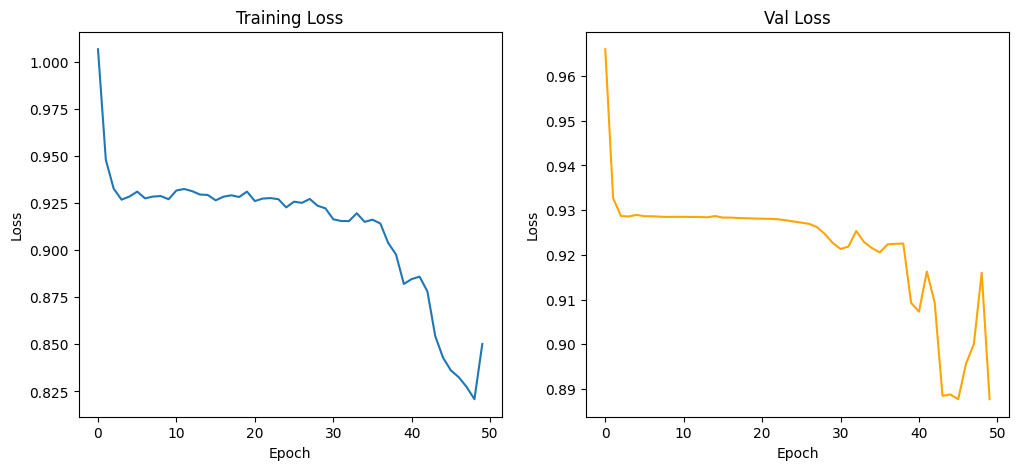

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses_1)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses_1, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
plt.show()

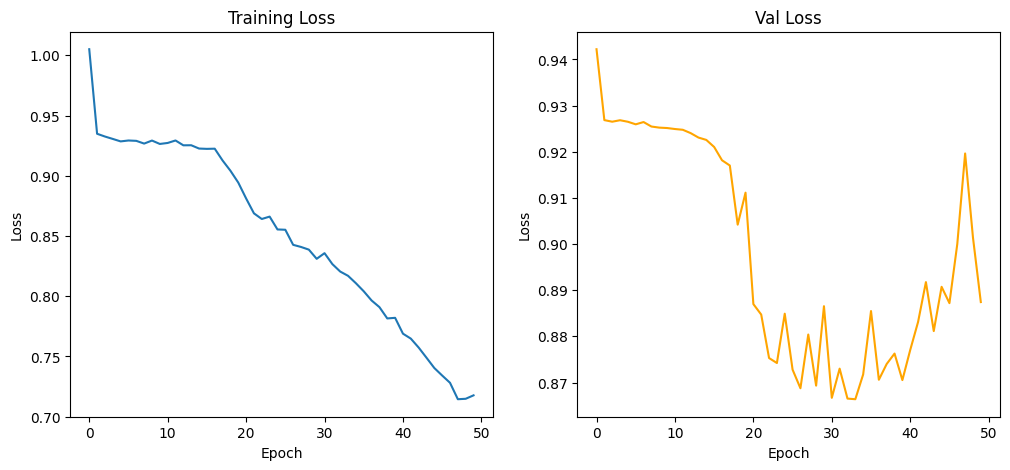

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses_2)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses_2, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
plt.show()

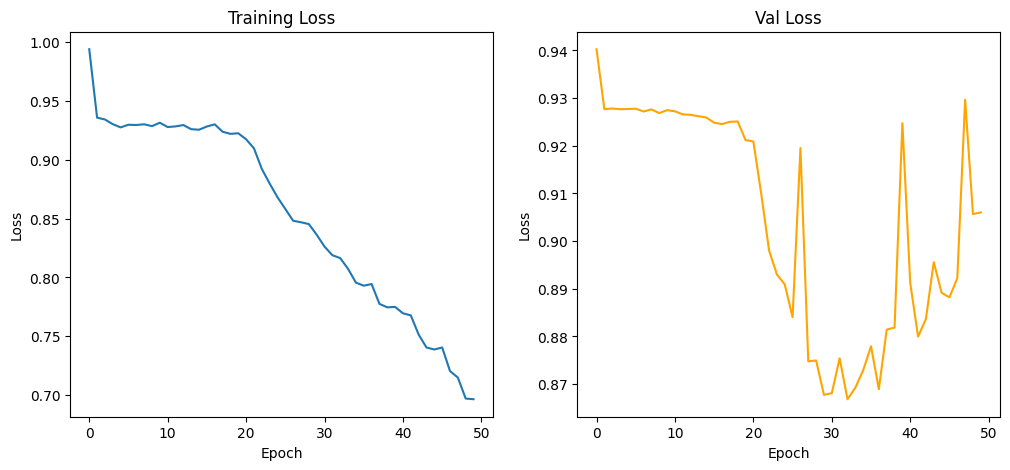

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses_3)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses_3, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
plt.show()

## 9. Evaluation

In [65]:
val_loss, val_acc = evaluate(
    model,
    val_loader,
    criterion,
    device
)
test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_acc)
print('Test accuracy: ', test_acc)

Evaluation on val/test dataset
Val accuracy:  0.5989690721649484
Test accuracy:  0.6391752577319587


In [66]:
val_loss, val_acc = evaluate(
    model_lstm,
    val_loader,
    criterion,
    device
)
test_loss, test_acc = evaluate(
    model_lstm,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_acc)
print('Test accuracy: ', test_acc)

Evaluation on val/test dataset
Val accuracy:  0.6309278350515464
Test accuracy:  0.6556701030927835


In [67]:
val_loss, val_acc = evaluate(
    model_bilstm,
    val_loader,
    criterion,
    device
)
test_loss, test_acc = evaluate(
    model_bilstm,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_acc)
print('Test accuracy: ', test_acc)

Evaluation on val/test dataset
Val accuracy:  0.6164948453608248
Test accuracy:  0.6556701030927835
